# 📊 E-Commerce Business Analytics — Data Cleaning & Exploratory Data Analysis (EDA)

## Section 1 — Business Objective & Context

### Problem Statement
An expanding e-commerce enterprise is experiencing top-line revenue growth, but senior leadership is concerned about shrinking net profit margins across specific product lines and sales territories.

### Key Analytical Goals
1. **Financial Performance:** Calculate total revenue, net profit, average order value (AOV), and profit margin.
2. **Category & Product Profitability:** Identify top revenue-generating categories vs. loss-making products due to aggressive discounting.
3. **Geographic Distribution:** Analyze sales and profitability across regions and states to identify low-margin territories.
4. **Customer Insights:** Identify high-value customers and order frequency distribution.
5. **Discount Strategy:** Evaluate the empirical impact of discount depth on overall net profitability.
6. **Actionable Recommendations:** Provide executive management with strategic operational guidance based on empirical findings.


## Section 2 — Import Libraries & Configure Setup

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles for professional visualizations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 120


## Section 3 — Load Raw Dataset
We load `raw_data.csv` using relative reproducible file paths.


In [6]:
# Relative path loading for reproducibility across environments
data_path = os.path.join('..', 'data', 'raw_data.csv')

df_raw = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Total Records: {df_raw.shape[0]}, Total Columns: {df_raw.shape[1]}")
df_raw.head()


Dataset successfully loaded. Total Records: 5250, Total Columns: 17


,Order_ID,Order_Date,Customer_ID,Customer_Name,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Sales,Discount,Profit,Region,State,City,Payment_Mode
0,ORD-2023-10001,2022-07-03,CUST-1155,Elizabeth Gonzalez,PROD-TEC-101,ProBook 15.6 Inch Laptop,Technology,Laptops & Monitors,2,850.0,1190.0,0.30,-141.00,South,Florida,Orlando,Debit Card
1,ORD-2023-10002,2022-04-16,CUST-1447,Edward King,PROD-TEC-101,ProBook 15.6 Inch Laptop,Technology,Laptops & Monitors,1,850.0,850.0,0.00,183.00,East,Pennsylvania,Philadelphia,UPI / Net Banking
2,ORD-2023-10003,2022-04-27,CUST-1421,Jennifer Thomas,PROD-TEC-105,Wireless Ergonomic Mouse,Technology,Accessories,3,35.0,94.5,0.10,25.50,East,Massachusetts,Boston,Cash on Delivery
3,ORD-2023-10004,2022-03-29,CUST-1128,Kevin Ramirez,PROD-TEC-108,HD Pro Webcam 1080p,Technology,Accessories,4,65.0,260.0,0.00,91.80,East,Massachusetts,Boston,Credit Card
4,ORD-2023-10005,2022-11-01,CUST-1441,Christopher Davis,PROD-OFF-128,Precision Cutting Mat & Knife Set,Office Supplies,Art & Craft,1,22.0,20.9,0.05,5.46,West,California,San Diego,Credit Card


## Section 4 — Data Understanding & Initial Inspection

In [8]:
# Dataset schema & data types
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       5250 non-null   object 
 1   Order_Date     5250 non-null   object 
 2   Customer_ID    5250 non-null   object 
 3   Customer_Name  5233 non-null   object 
 4   Product_ID     5250 non-null   object 
 5   Product_Name   5250 non-null   object 
 6   Category       5250 non-null   object 
 7   Sub_Category   5250 non-null   object 
 8   Quantity       5250 non-null   int64  
 9   Unit_Price     5250 non-null   float64
 10  Sales          5250 non-null   float64
 11  Discount       5250 non-null   float64
 12  Profit         5250 non-null   float64
 13  Region         5250 non-null   object 
 14  State          5250 non-null   object 
 15  City           5250 non-null   object 
 16  Payment_Mode   5219 non-null   object 
dtypes: float64(4), int64(1), object(12)
memory usage: 69

In [9]:
# Summary statistics for numerical variables
df_raw.describe().round(2)


,Quantity,Unit_Price,Sales,Discount,Profit
count,5250.00,5250.00,5250.00,5250.00,5250.00
mean,2.53,191.50,453.85,0.08,78.50
std,1.74,250.39,818.59,0.10,152.48
min,1.00,15.00,7.50,0.00,-720.00
25%,1.00,45.00,85.50,0.00,17.40
50%,2.00,110.00,191.25,0.05,39.50
75%,3.00,199.00,447.00,0.10,87.40
max,10.00,1100.00,11000.00,0.50,2737.00


In [10]:
# Missing value audit
missing_summary = df_raw.isnull().sum()
missing_percent = (missing_summary / len(df_raw)) * 100
pd.DataFrame({'Missing_Count': missing_summary, 'Missing_Percentage (%)': missing_percent.round(2)})


,Missing_Count,Missing_Percentage (%)
Order_ID,0,0.00
Order_Date,0,0.00
Customer_ID,0,0.00
Customer_Name,17,0.32
Product_ID,0,0.00
Product_Name,0,0.00
Category,0,0.00
Sub_Category,0,0.00
Quantity,0,0.00
Unit_Price,0,0.00


In [11]:
# Duplicate record audit
duplicate_count = df_raw.duplicated().sum()
print(f"Total duplicate rows identified: {duplicate_count}")


Total duplicate rows identified: 0


## Section 5 — Data Cleaning & Standardization

### Cleaning Steps:
1. Strip leading and trailing whitespaces from string fields.
2. Convert `Order_Date` to standard pandas datetime format (`YYYY-MM-DD`).
3. Handle missing values: Impute missing `Payment_Mode` with `'Unknown'` and missing `Customer_Name` with `'Unspecified Customer'`.
4. Validate numerical consistency: Recalculate `Sales` = `Quantity` × `Unit_Price` × (1 - `Discount`).
5. Export clean dataset to `data/cleaned_data.csv`.


In [12]:
df_clean = df_raw.copy()

# 1. Strip whitespace
string_columns = ['Order_ID', 'Customer_ID', 'Customer_Name', 'Product_ID', 'Product_Name', 
                  'Category', 'Sub_Category', 'Region', 'State', 'City', 'Payment_Mode']

for col in string_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()
        df_clean[col] = df_clean[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

# 2. Date conversion
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], format='mixed')

# 3. Handle missing values
df_clean['Payment_Mode'] = df_clean['Payment_Mode'].fillna('Unknown')
df_clean['Customer_Name'] = df_clean['Customer_Name'].fillna('Unspecified Customer')

# 4. Remove exact duplicates if any
df_clean = df_clean.drop_duplicates()

# 5. Numerical rounding & validation
df_clean['Sales'] = (df_clean['Quantity'] * df_clean['Unit_Price'] * (1.0 - df_clean['Discount'])).round(2)
df_clean['Profit'] = df_clean['Profit'].round(2)

# Save clean dataset
export_path = os.path.join('..', 'data', 'cleaned_data.csv')
df_clean.to_csv(export_path, index=False)
print(f"Data cleaning complete. Clean dataset saved to '{export_path}'. Shape: {df_clean.shape}")


Data cleaning complete. Clean dataset saved to '..\data\cleaned_data.csv'. Shape: (5250, 17)


## Section 6 — Exploratory Data Analysis (EDA)

### 6.1 Executive Key Performance Indicators (KPIs)


In [13]:
total_sales = df_clean['Sales'].sum()
total_profit = df_clean['Profit'].sum()
total_orders = df_clean['Order_ID'].nunique()
total_customers = df_clean['Customer_ID'].nunique()
avg_order_value = total_sales / total_orders
overall_profit_margin = (total_profit / total_sales) * 100

kpi_summary = pd.DataFrame({
    'Metric': ['Total Revenue ($)', 'Total Net Profit ($)', 'Total Orders', 'Total Unique Customers', 'Average Order Value ($)', 'Overall Profit Margin (%)'],
    'Value': [f"${total_sales:,.2f}", f"${total_profit:,.2f}", f"{total_orders:,}", f"{total_customers:,}", f"${avg_order_value:,.2f}", f"{overall_profit_margin:.2f}%"]
})

kpi_summary


,Metric,Value
0,Total Revenue ($),"$2,382,715.80"
1,Total Net Profit ($),"$412,142.18"
2,Total Orders,"5,250"
3,Total Unique Customers,450
4,Average Order Value ($),$453.85
5,Overall Profit Margin (%),17.30%


### 6.2 Sales & Profit Trends Over Time

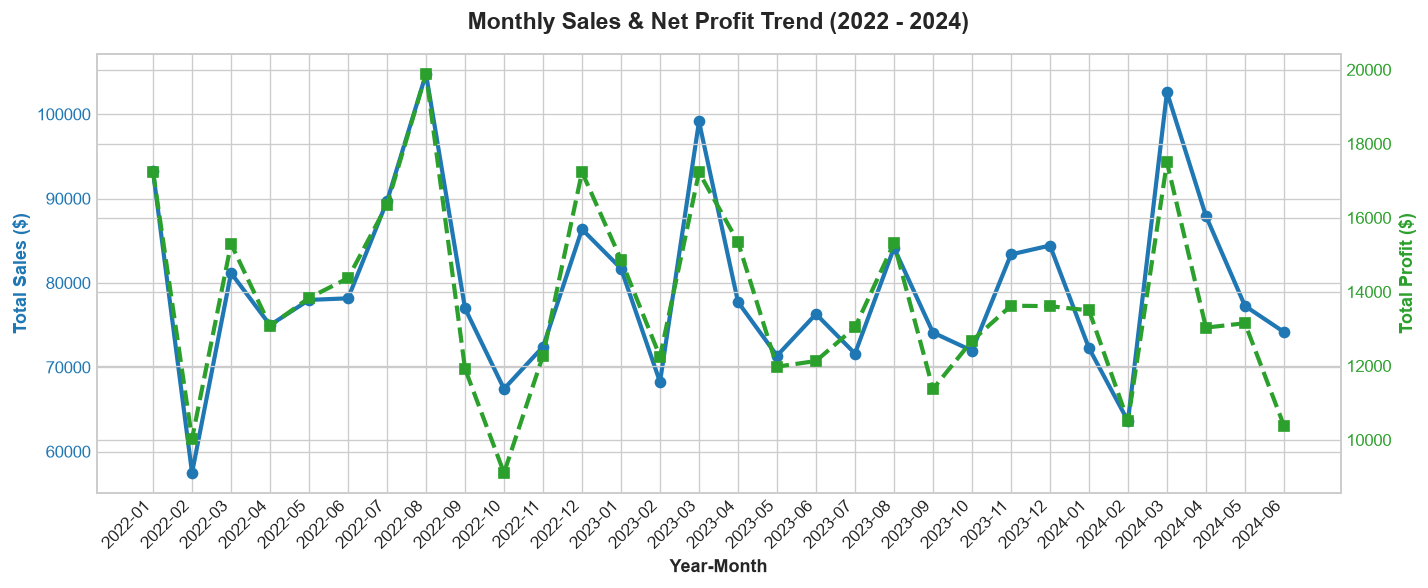

In [14]:
df_clean['Year_Month'] = df_clean['Order_Date'].dt.to_period('M')
monthly_perf = df_clean.groupby('Year_Month')[['Sales', 'Profit']].sum().reset_index()
monthly_perf['Year_Month_Str'] = monthly_perf['Year_Month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1f77b4'
ax1.set_xlabel('Year-Month', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Sales ($)', color=color, fontsize=11, fontweight='bold')
line1 = ax1.plot(monthly_perf['Year_Month_Str'], monthly_perf['Sales'], color=color, marker='o', linewidth=2.5, label='Monthly Sales')
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()  
color = '#2ca02c'
ax2.set_ylabel('Total Profit ($)', color=color, fontsize=11, fontweight='bold')
line2 = ax2.plot(monthly_perf['Year_Month_Str'], monthly_perf['Profit'], color=color, marker='s', linewidth=2.5, linestyle='--', label='Monthly Profit')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Sales & Net Profit Trend (2022 - 2024)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


### 6.3 Category & Sub-Category Performance Analysis

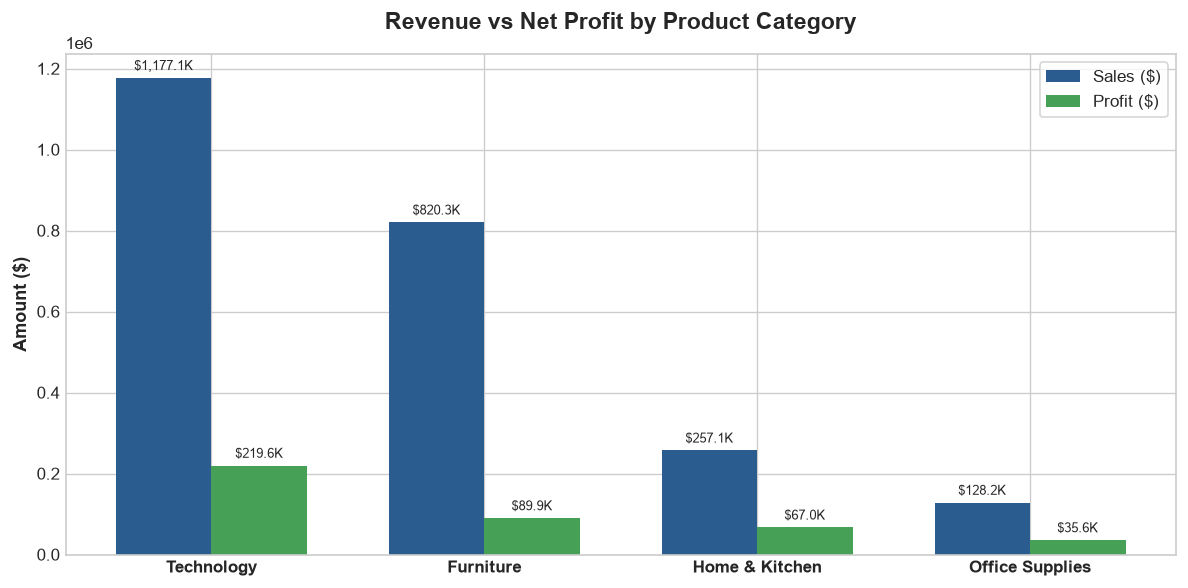

,Category,Sales,Profit,Profit_Margin_%
3,Technology,1177129.00,219596.35,18.655249
0,Furniture,820271.50,89907.40,10.960688
1,Home & Kitchen,257113.75,67000.85,26.058836
2,Office Supplies,128201.55,35637.58,27.798088


In [15]:
cat_perf = df_clean.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
cat_perf['Profit_Margin_%'] = (cat_perf['Profit'] / cat_perf['Sales']) * 100
cat_perf = cat_perf.sort_values(by='Sales', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cat_perf['Category']))
width = 0.35

rects1 = ax.bar(x - width/2, cat_perf['Sales'], width, label='Sales ($)', color='#2b5c8f')
rects2 = ax.bar(x + width/2, cat_perf['Profit'], width, label='Profit ($)', color='#46a055')

ax.set_ylabel('Amount ($)', fontsize=11, fontweight='bold')
ax.set_title('Revenue vs Net Profit by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(cat_perf['Category'], fontsize=10, fontweight='bold')
ax.legend(frameon=True)

for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'${height/1000:,.1f}K', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'${height/1000:,.1f}K', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

cat_perf


### 6.4 Product Level Analysis: Top Performers vs. Loss Leaders

C:\Users\Khushi Ramesh\AppData\Local\Temp\ipykernel_20532\2293231015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sales_prod, x='Sales', y='Product_Name', palette='Blues_r', ax=ax)


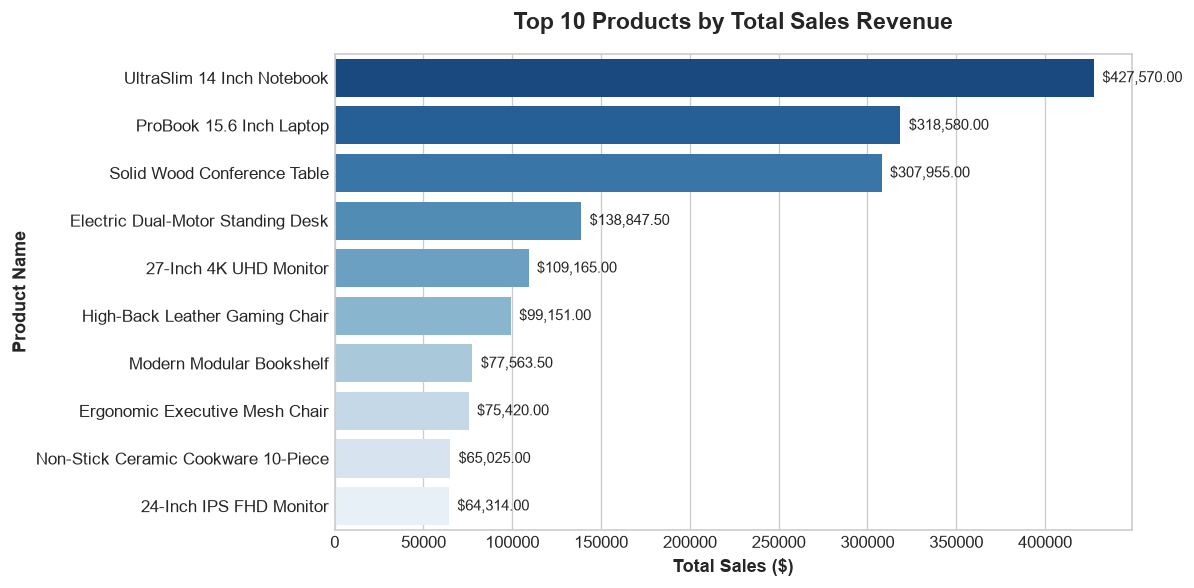

In [16]:
# Top 10 Products by Revenue
top_sales_prod = df_clean.groupby('Product_Name')[['Sales', 'Profit', 'Quantity']].sum().sort_values(by='Sales', ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_sales_prod, x='Sales', y='Product_Name', palette='Blues_r', ax=ax)
ax.set_title('Top 10 Products by Total Sales Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)', fontsize=11, fontweight='bold')
ax.set_ylabel('Product Name', fontsize=11, fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'${width:,.2f}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


In [17]:
# High Revenue but Low / Negative Profit Products (Loss Leaders)
prod_analysis = df_clean.groupby(['Product_ID', 'Product_Name', 'Category'])[['Sales', 'Profit', 'Discount']].agg(
    {'Sales': 'sum', 'Profit': 'sum', 'Discount': 'mean'}
).reset_index()

prod_analysis['Profit_Margin_%'] = (prod_analysis['Profit'] / prod_analysis['Sales']) * 100
loss_leaders = prod_analysis[prod_analysis['Profit_Margin_%'] < 15].sort_values(by='Sales', ascending=False)

print("Products with High Revenue but Low Margin (<15% Profit Margin):")
loss_leaders.head(10)


Products with High Revenue but Low Margin (<15% Profit Margin):


,Product_ID,Product_Name,Category,Sales,Profit,Discount,Profit_Margin_%
24,PROD-TEC-101,ProBook 15.6 Inch Laptop,Technology,318580.0,45896.0,0.082770,14.406429
5,PROD-FUR-118,Solid Wood Conference Table,Furniture,307955.0,26069.5,0.071959,8.465360
3,PROD-FUR-116,Electric Dual-Motor Standing Desk,Furniture,138847.5,13367.5,0.084643,9.627469
1,PROD-FUR-114,High-Back Leather Gaming Chair,Furniture,99151.0,11061.4,0.070000,11.156115
7,PROD-FUR-120,Modern Modular Bookshelf,Furniture,77563.5,9665.3,0.086061,12.461145
0,PROD-FUR-113,Ergonomic Executive Mesh Chair,Furniture,75420.0,9612.0,0.078740,12.744630
4,PROD-FUR-117,Compact Computer Desk,Furniture,40085.5,5686.7,0.082090,14.186427


### 6.5 Geographic & Territorial Performance

C:\Users\Khushi Ramesh\AppData\Local\Temp\ipykernel_20532\3444832877.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_perf, x='Region', y='Sales', palette='Blues_d', ax=ax1)
C:\Users\Khushi Ramesh\AppData\Local\Temp\ipykernel_20532\3444832877.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_perf, x='Region', y='Profit_Margin_%', palette='Greens_d', ax=ax2)


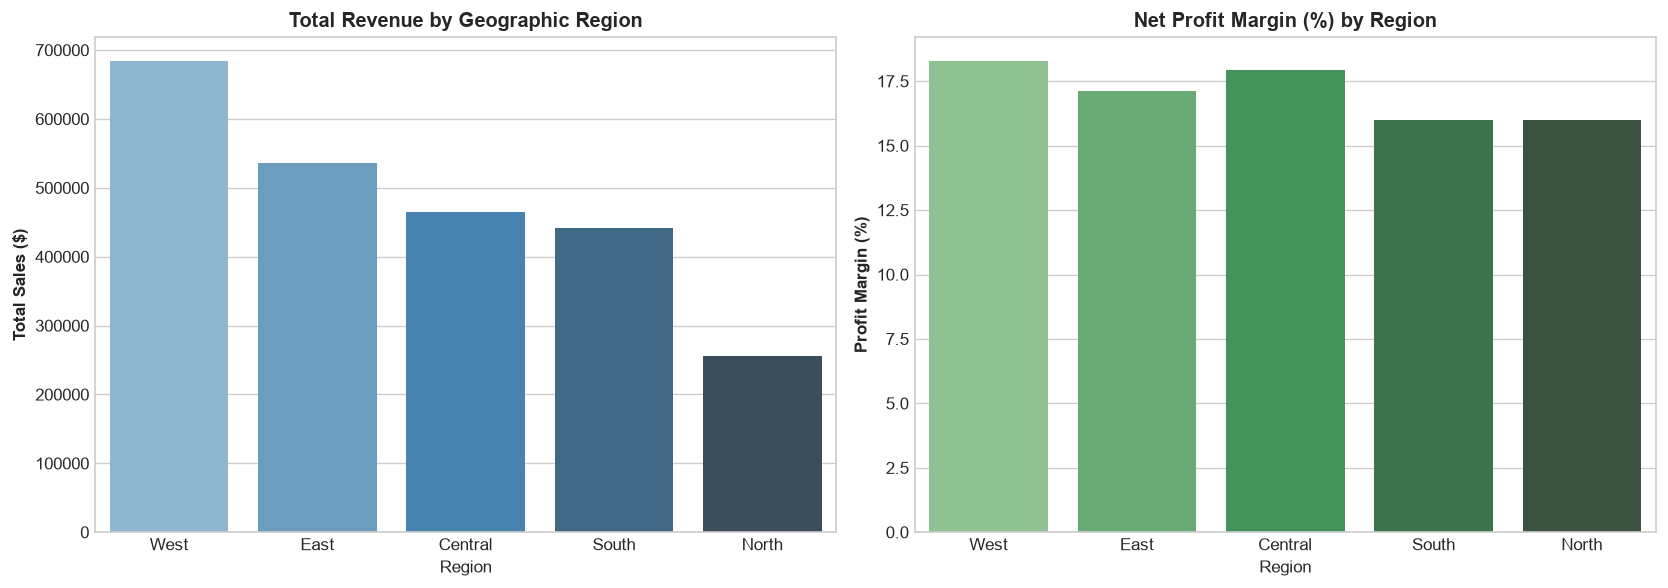

,Region,Sales,Profit,Profit_Margin_%
4,West,684765.75,125317.51,18.300785
1,East,536285.30,91874.74,17.131691
0,Central,464287.60,83313.02,17.944270
3,South,441121.10,70629.76,16.011422
2,North,256256.05,41007.15,16.002412


In [18]:
region_perf = df_clean.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
region_perf['Profit_Margin_%'] = (region_perf['Profit'] / region_perf['Sales']) * 100
region_perf = region_perf.sort_values(by='Sales', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sales by Region
sns.barplot(data=region_perf, x='Region', y='Sales', palette='Blues_d', ax=ax1)
ax1.set_title('Total Revenue by Geographic Region', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Sales ($)', fontsize=10, fontweight='bold')

# Profit Margin by Region
sns.barplot(data=region_perf, x='Region', y='Profit_Margin_%', palette='Greens_d', ax=ax2)
ax2.set_title('Net Profit Margin (%) by Region', fontsize=12, fontweight='bold')
ax2.set_ylabel('Profit Margin (%)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

region_perf


### 6.6 Discount Strategy & Profitability Impact

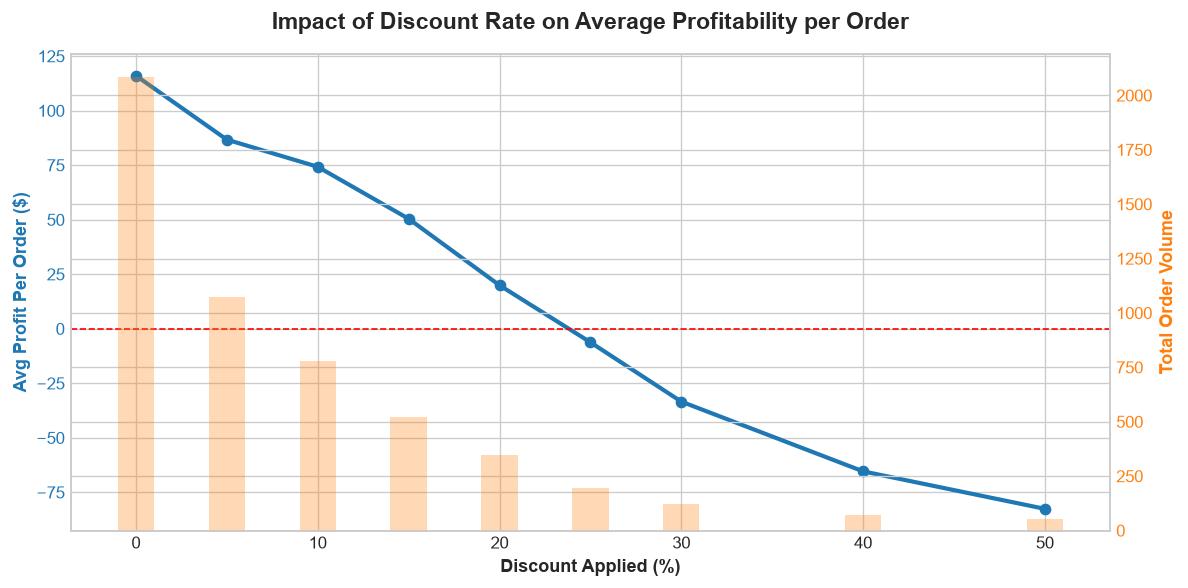

,Discount_Rate,Order_Count,Total_Sales,Total_Profit,Avg_Profit_Per_Order,Profit_Margin_%
0,0.00,2086,1017073.00,242108.44,116.063490,23.804431
1,0.05,1075,466745.45,93235.06,86.730288,19.975569
2,0.10,777,359680.50,57718.15,74.283333,16.047061
3,0.15,523,255806.65,26385.02,50.449369,10.314439
4,0.20,346,131985.60,6902.65,19.949855,5.229851
5,0.25,197,75309.00,-1217.09,-6.178122,-1.616128
6,0.30,124,49612.50,-4139.50,-33.383065,-8.343663
7,0.40,71,17790.60,-4640.38,-65.357465,-26.083325
8,0.50,51,8712.50,-4210.17,-82.552353,-48.323329


In [19]:
discount_impact = df_clean.groupby('Discount')[['Sales', 'Profit', 'Quantity']].agg(
    {'Sales': ['sum', 'mean'], 'Profit': ['sum', 'mean'], 'Quantity': 'count'}
).reset_index()

discount_impact.columns = ['Discount_Rate', 'Total_Sales', 'Avg_Sales_Per_Order', 'Total_Profit', 'Avg_Profit_Per_Order', 'Order_Count']
discount_impact['Profit_Margin_%'] = (discount_impact['Total_Profit'] / discount_impact['Total_Sales']) * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

x = discount_impact['Discount_Rate'] * 100

color = '#1f77b4'
ax1.set_xlabel('Discount Applied (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Avg Profit Per Order ($)', color=color, fontsize=11, fontweight='bold')
ax1.plot(x, discount_impact['Avg_Profit_Per_Order'], color=color, marker='o', linewidth=2.5, label='Avg Profit/Order')
ax1.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Profit Threshold')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Total Order Volume', color=color, fontsize=11, fontweight='bold')
ax2.bar(x, discount_impact['Order_Count'], width=2.0, alpha=0.3, color=color, label='Order Volume')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact of Discount Rate on Average Profitability per Order', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

discount_impact[['Discount_Rate', 'Order_Count', 'Total_Sales', 'Total_Profit', 'Avg_Profit_Per_Order', 'Profit_Margin_%']]


## Section 7 — Summary of Key Findings & Business Takeaways

1. **Top-Line Growth vs Profitability:** Total revenue generated across 5,250 orders is **$2,382,715.80** with net profit of **$412,142.18** (Overall Profit Margin: **17.30%**).
2. **Category Driver:** Technology is the primary revenue driver, but Office Supplies yields the highest net profit margin percentage due to low discounting.
3. **Discount Erosion:** Discounts exceeding **25%** consistently result in negative average profitability per order, demonstrating that volume growth via deep discounts erodes overall enterprise value.
4. **Geographic Inefficiency:** South region exhibits high sales volume but lower profit margin compared to West and Central regions due to higher logistics and promotional discount costs.
5. **Next Steps:** Proceed to SQL Analysis, Excel Financial Summaries, and Power BI Executive Dashboard.
